In [2]:

import osmnx as ox
import os
from dotenv import load_dotenv
import folium
import random
import networkx as nx
import heapq
import pandas as pd
import numpy as np
import time

In [3]:
load_dotenv()

apikey = os.getenv("THUNDERFOREST_API_KEY")

In [4]:

def add_elevation_data_to_graph(graph, batch_size: int = 16, pause: float = 1.0, verbose: bool = False):
    """
    Adds elevation data to graph nodes and calculates edge grades.
    Based on the provided snippet and osmnx functionalities.
    """
    node_points = pd.Series({n: f"{d['y']:.6f},{d['x']:.6f}" for n, d in graph.nodes(data=True)})
    n_calls = int(np.ceil(len(node_points) / batch_size))
    domain = "https://api.open-elevation.com"
    url_base = "https://api.open-elevation.com/api/v1/lookup?locations={}"

    if verbose:
        print(f"Requesting node elevations from {domain!r} in {n_calls} request(s)")
        print("Number of nodes: ", len(node_points))

    results = []
    for i in range(0, len(node_points), batch_size):
        chunk = node_points.iloc[i : i + batch_size]
        locations = "|".join(chunk)
        url = url_base.format(locations)

        try:
            # Pass the pause parameter to _elevation_request
            response_json = ox.elevation._elevation_request(url, pause=pause)
        except Exception as e:
            print(f"Error with request {url}: {e}")
            break
            
        if "results" in response_json and len(response_json["results"]) > 0:
            results.extend(response_json["results"])
        else:
            print(f"Warning: No results or unexpected response for chunk {i//batch_size + 1}: {response_json}")
            pass

        if verbose and (i // batch_size) % 10 == 0:
            print(f"Batch {i//batch_size + 1}/{n_calls} processed, {len(results)} results so far")

    # Sanity check that all our vectors have the same number of elements
    if not (len(results) == len(node_points)):
        err_msg = (f"Graph has {len(graph.nodes):,} nodes ({len(node_points)} points sent) "
                   f"but received {len(results):,} results from {domain!r}.")
        # If response_json is from the last call, it might be useful for debugging.
        # Consider logging the full list of URLs or problematic chunks if this error occurs.
        # err_msg += f"\nLast response (may not be the only problematic one): {response_json}"
        raise Exception(err_msg)

    # Add elevation as an attribute to the nodes
    # Ensure nodes in df_elev are aligned with nodes in graph for direct assignment
    df_elev = pd.DataFrame(index=node_points.index)
    df_elev["elevation"] = [result["elevation"] for result in results] # Assumes results are in order
    
    nx.set_node_attributes(graph, name="elevation", values=df_elev["elevation"].to_dict())
    if verbose:
        print(f"Added 'elevation' attribute from {domain!r} to all {len(graph.nodes())} nodes.")
    
    # Add edge grades and absolute edge grades
    graph_with_grades = ox.elevation.add_edge_grades(graph)
    if verbose:
        print("Added 'grade' and 'grade_abs' attributes to edges.")
        
    return graph_with_grades

  center = [40.006067, -105.264977],
  zoom = 16

In [5]:
z = 600
x = 40.006067
y = -105.264977

In [6]:
graph = ox.graph_from_point((x, y), dist=z, network_type='walk')

In [7]:
graph = add_elevation_data_to_graph(graph)

In [8]:
tile_layers = {
    "OpenCycleMap": f"https://tile.thunderforest.com/cycle/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Transport": f"https://tile.thunderforest.com/transport/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Landscape": f"https://tile.thunderforest.com/landscape/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Outdoors": f"https://tile.thunderforest.com/outdoors/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Transport Dark": f"https://tile.thunderforest.com/transport-dark/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Spinal Map": f"https://tile.thunderforest.com/spinal-map/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Pioneer": f"https://tile.thunderforest.com/pioneer/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Mobile Atlas": f"https://tile.thunderforest.com/mobile-atlas/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Neighbourhood": f"https://tile.thunderforest.com/neighbourhood/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Atlas": f"https://tile.thunderforest.com/atlas/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
}

In [9]:
# Create a folium map centered at your point
m = folium.Map(location=[x, y], zoom_start=15.5)

# Add your custom tile layers
for name, url in tile_layers.items():
    folium.TileLayer(
        tiles=url,
        attr='Thunderforest',
        name=name
    ).add_to(m)

# Convert the graph to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(graph)

# Add the edges (streets) to the map
folium.GeoJson(
    edges,
    style_function=lambda x: {
        'color': 'red',
        'weight': 1,
        'opacity': 0.7
    }
).add_to(m)

# Add the nodes (intersections) to the map
folium.GeoJson(
    nodes,
    marker=folium.CircleMarker(
        radius=2,
        fill_color='blue',
        fill_opacity=0.7,
        color='blue'
    )
).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Display the map
m

In [10]:
# Get a list of all nodes in the graph
all_nodes = list(graph.nodes())

# Choose 2 random nodes
origin = random.choice(all_nodes)
destination = random.choice(all_nodes)

# Make sure they're different
while origin == destination:
    destination = random.choice(all_nodes)

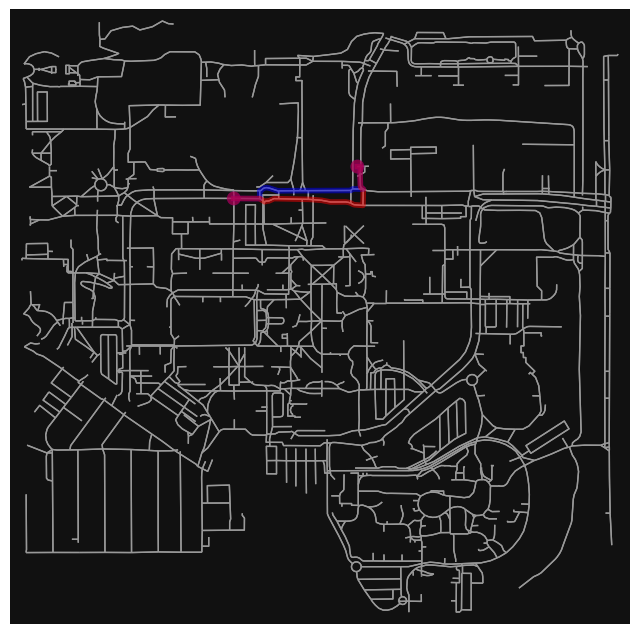

In [11]:
# First path - shortest by length
route1 = nx.shortest_path(graph, origin, destination, weight='length')

# Second path - add penalty to edges in the first path
G_temp = graph.copy()
for u, v in zip(route1[:-1], route1[1:]):
    # Find the edge with minimum length
    min_length = float('inf')
    for edge_data in graph.get_edge_data(u, v).values():
        if edge_data.get('length', float('inf')) < min_length:
            min_length = edge_data.get('length')
    
    # Add penalty to all edges between these nodes
    for k in G_temp.get_edge_data(u, v):
        G_temp[u][v][k]['length'] *= 1.5  # 50% penalty

# Find second path with penalties
route2 = nx.shortest_path(G_temp, origin, destination, weight='length')

# Plot routes
fig, ax = ox.plot_graph_routes(graph, [route1, route2], route_colors=['blue', 'red'],
                              route_linewidth=6, node_size=0)

In [12]:
def A_star(graph, start, end, heuristic_fn, edge_weight_fn):
    """
    Implementation of A* algorithm to find the shortest path between two nodes.
    
    Args:
        graph: NetworkX graph
        start: Starting node
        end: Destination node
        heuristic_fn: Function that estimates distance from node to goal
        edge_weight_fn: Function that returns the weight of an edge
    
    Returns:
        List of nodes representing the shortest path
    """
    # Priority queue for open nodes
    open_set = []
    heapq.heappush(open_set, (0, start))
    
    # For node n, came_from[n] is the node immediately preceding it on the path
    came_from = {}
    
    # For node n, g_score[n] is the cost of the cheapest path from start to n
    g_score = {node: float('inf') for node in graph.nodes()}
    g_score[start] = 0
    
    # For node n, f_score[n] = g_score[n] + heuristic(n)
    f_score = {node: float('inf') for node in graph.nodes()}
    f_score[start] = heuristic_fn(graph, start, end)
    
    # Nodes that have been visited
    closed_set = set()
    
    while open_set:
        # Get node with lowest f_score
        current_f_score, current = heapq.heappop(open_set)
        
        if current == end:
            # Reconstruct path
            path_nodes = [current]
            path_edges = []
            
            while current in came_from:
                prev_node, edge_key = came_from[current]
                path_nodes.append(prev_node)
                path_edges.append((prev_node, current, edge_key))
                current = prev_node
                
            # Return reversed path
            return path_nodes[::-1], path_edges[::-1]
        
        closed_set.add(current)
        
        # Check all neighbors
        for neighbor in graph.neighbors(current):
            if neighbor in closed_set:
                continue
            
            # Calculate tentative g_score
            min_edge_weight = float('inf')
            for edge_key in graph.get_edge_data(current, neighbor):
                edge_weight = edge_weight_fn(graph, current, neighbor, edge_key)
                if edge_weight < min_edge_weight:
                    min_edge_weight = edge_weight
            tentative_g_score = g_score[current] + min_edge_weight
            
            if tentative_g_score < g_score[neighbor]:
                # This path is better than any previous one
                
                # Find the best edge to use (the one that gave us this tentative_g_score)
                best_edge_key = None
                best_edge_weight = float('inf')
                
                for edge_key in graph.get_edge_data(current, neighbor):
                    edge_weight = edge_weight_fn(graph, current, neighbor, edge_key)
                    if edge_weight < best_edge_weight:
                        best_edge_weight = edge_weight
                        best_edge_key = edge_key
                
                # Store both the previous node and the specific edge used
                came_from[neighbor] = (current, best_edge_key)
                g_score[neighbor] = tentative_g_score
                f_score[neighbor] = g_score[neighbor] + heuristic_fn(graph, neighbor, end)
                heapq.heappush(open_set, (f_score[neighbor], neighbor))
    # No path found
    return None

def heuristic_distance(graph, node, goal):
    """
    Heuristic function that estimates the distance from node to goal.
    In this case, using Euclidean distance between the nodes.
    
    Args:
        graph: NetworkX graph
        node: Current node
        goal: Goal node
        
    Returns:
        Estimated distance to goal
    """
    # Get node coordinates
    node_y = graph.nodes[node]['y']
    node_x = graph.nodes[node]['x']
    goal_y = graph.nodes[goal]['y']
    goal_x = graph.nodes[goal]['x']
    
    # Calculate Euclidean distance
    return ((node_y - goal_y) ** 2 + (node_x - goal_x) ** 2) ** 0.5

def edge_weight(graph, u, v, edge_key=None, elevation_weight=1.0):
    """
    Function to calculate edge weight considering both distance and elevation change.
    
    Args:
        graph: NetworkX graph
        u: Source node
        v: Target node
        edge_key: Specific edge key (for multigraph support)
        elevation_weight: Factor to control importance of elevation change
        
    Returns:
        Combined weight of the edge
    """
    if edge_key is not None:
        # Get specific edge
        edge_data = graph.get_edge_data(u, v)[edge_key]
        length = edge_data.get('length', 0)
    else:
        # Find minimum length edge (default behavior)
        min_length = float('inf')
        for edge_data in graph.get_edge_data(u, v).values():
            if edge_data.get('length', float('inf')) < min_length:
                min_length = edge_data.get('length')
        length = min_length
    
    # Calculate elevation values
    elevation_u = graph.nodes[u].get('elevation', 0)
    elevation_v = graph.nodes[v].get('elevation', 0)
    # print(elevation_u, elevation_v)
    
    # Calculate grade (elevation change / distance)
    elevation_change = elevation_v - elevation_u
    grade = abs(elevation_change / length) if length > 0 else 0
    
    # Combined weight: distance + (elevation_weight * grade)
    return length + (elevation_weight * grade)

In [13]:
route3, route3_path = A_star(
        graph, 
        origin, 
        destination, 
        heuristic_distance,
        lambda g, u, v, edge_key: edge_weight(g, u, v, edge_key, 15)
    )

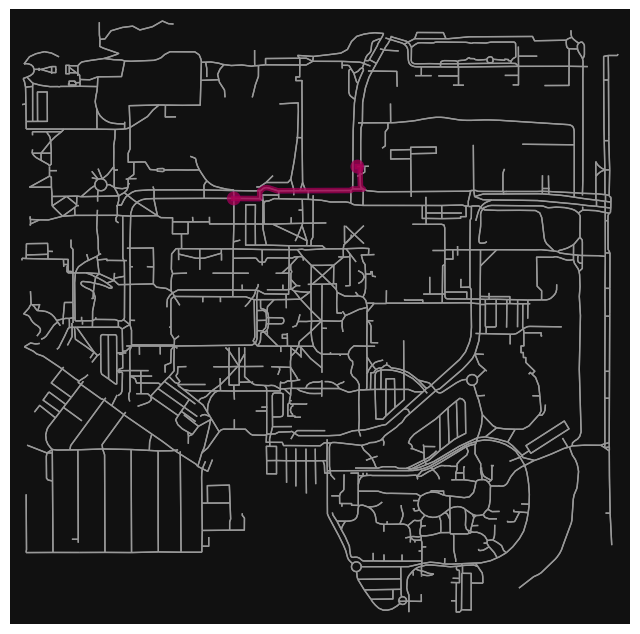

In [14]:
fig, ax = ox.plot_graph_routes(graph, [route1, route3], route_colors=['blue', 'red'],
                              route_linewidth=6, node_size=0)

In [15]:
route1

[4753696721,
 4753696736,
 5468400696,
 11285742493,
 5468400694,
 5182099094,
 12512971076,
 11285742491,
 4753696757,
 4753696754,
 4753696755,
 9088797925,
 9088797924,
 5534410803]